# Projeto de Autenticação Facial com Liveness Ativo e Reconhecimento 👤🛡️

Este notebook apresenta uma solução de **Autenticação Facial** projetada para atuar como uma camada complementar de segurança à tradicional senha. A motivação deste projeto reside no cenário de fraudes em que um cliente, mesmo após a digitação da senha correta, nega a contratação de um serviço ou produto. A biometria facial atua como uma evidência robusta de que o titular de fato estava presente e ativo no momento da transação.

A solução é composta por três capacidades principais:
1. **Detecção e Alinhamento Facial**: Localização do rosto em tempo real via webcam.
2. **Liveness Ativo (Detecção de Piscada)**: Validação de que a pessoa em frente à câmera é real e ativa, mitigando ataques com fotos impressas ou telas de celulares (liveness por piscada).
3. **Identificação Facial**: Comparação da face capturada com as imagens cadastradas em um banco de dados local.

### Stack Tecnológica
* **Linguagem**: Python
* **Visão Computacional**: OpenCV (processamento de vídeo e imagens)
* **Extração de Landmarks**: MediaPipe Tasks API (Face Landmarker)
* **Reconhecimento Facial**: DeepFace (modelo VGG-Face)
* **Visualização e Logs**: Matplotlib, Pandas, CSV


## 0. Instalação

Antes de executar o notebook, certifique-se de que possui as dependências instaladas. Você pode instalá-las rodando a instrução abaixo (removendo o comentário `#`):

```bash
# %pip install -r requirements.txt
```


In [1]:
import os
import time
import pickle
import csv
from datetime import datetime
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from deepface import DeepFace
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision

print("Versão do OpenCV:", cv2.__version__)
print("Versão do MediaPipe:", mp.__version__)



Versão do OpenCV: 4.13.0
Versão do MediaPipe: 0.10.35


## 1. Configuração

Definimos abaixo os caminhos absolutos das pastas do projeto e os parâmetros operacionais no dicionário `CONFIG`:
* `CAM_INDEX`: Índice da câmera (geralmente 0 para a webcam padrão).
* `EAR_THRESHOLD`: Limiar do EAR (Eye Aspect Ratio) para determinar se o olho está fechado (valores menores que este limiar indicam fechamento).
* `BLINK_THRESHOLD`: Limiar de ativação do blendshape de piscada do MediaPipe para determinar olho fechado.
* `PISCADAS_NECESSARIAS`: Quantidade de piscadas exigidas no desafio de liveness.
* `LIVENESS_TIMEOUT`: Tempo limite (em segundos) para que o usuário complete o desafio.
* `MODELO_IDENTIFICACAO`: Modelo de DeepFace a ser utilizado (ex.: "VGG-Face").
* `DETECTOR_BACKEND`: Detector de face a ser utilizado no DeepFace (ex.: "opencv").


In [2]:
BASE_DIR = Path.cwd()
DATABASE_DIR = BASE_DIR / "database"
FAILED_DIR = BASE_DIR / "failed_attempts"
MODELS_DIR = BASE_DIR / "models"

# Garantir a existência dos diretórios
DATABASE_DIR.mkdir(parents=True, exist_ok=True)
FAILED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "CAM_INDEX": 0,
    "EAR_THRESHOLD": 0.21,
    "BLINK_THRESHOLD": 0.5,
    "PISCADAS_NECESSARIAS": 2,
    "LIVENESS_TIMEOUT": 15,
    "MODELO_IDENTIFICACAO": "VGG-Face",
    "DETECTOR_BACKEND": "opencv"
}

print("Diretórios criados/verificados com sucesso:")
print(f" - Banco de dados: {DATABASE_DIR}")
print(f" - Tentativas com falha: {FAILED_DIR}")
print(f" - Modelos: {MODELS_DIR}")


Diretórios criados/verificados com sucesso:
 - Banco de dados: c:\Users\stgab\OneDrive\Documentos\GitHub\Grupo_2_atividades\Autenticacao_facial_final\database
 - Tentativas com falha: c:\Users\stgab\OneDrive\Documentos\GitHub\Grupo_2_atividades\Autenticacao_facial_final\failed_attempts
 - Modelos: c:\Users\stgab\OneDrive\Documentos\GitHub\Grupo_2_atividades\Autenticacao_facial_final\models


## 2. Modelo do MediaPipe

Para realizar a extração de marcos faciais de forma local e precisa, é necessário baixar o arquivo de modelo pré-treinado `.task` do MediaPipe. O código a seguir verifica se o arquivo `face_landmarker.task` existe na pasta `models/` e o baixa caso contrário.


In [3]:
import urllib.request

def baixar_modelo():
    modelo_path = MODELS_DIR / "face_landmarker.task"
    url = "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task"
    if not modelo_path.exists():
        print("Baixando o modelo Face Landmarker (este processo pode demorar alguns instantes)...")
        urllib.request.urlretrieve(url, str(modelo_path))
        print("Download concluído com sucesso!")
    else:
        print("O modelo Face Landmarker já existe localmente.")

baixar_modelo()


O modelo Face Landmarker já existe localmente.


## 3. Liveness Ativo por Piscada

O teste de liveness ativo por piscada é uma das defesas mais eficazes contra falsificação por foto (impressa ou digital). Uma imagem estática não apresenta a dinâmica natural de fechar e abrir os olhos.

Utilizamos a **Tasks API** do MediaPipe para extrair:
1. **Coordenadas Tridimensionais dos Olhos**: Calculamos o **Eye Aspect Ratio (EAR)**, que mede a relação entre a distância vertical e horizontal dos olhos. Quando os olhos se fecham, o EAR cai drasticamente.
2. **Blendshapes**: O MediaPipe fornece estimativas de ativação de expressões faciais. As categorias `eyeBlinkLeft` e `eyeBlinkRight` nos dão pontuações diretas de fechamento das pálpebras de 0.0 a 1.0.

A combinação de ambas as métricas aumenta drasticamente a robustez da detecção.


In [4]:
_FL_PATH = str(MODELS_DIR / "face_landmarker.task")
OLHO_ESQ = [33, 160, 158, 133, 153, 144]
OLHO_DIR = [362, 385, 387, 263, 373, 380]

def _criar_landmarker():
    opts = vision.FaceLandmarkerOptions(
        base_options=mp_python.BaseOptions(model_asset_path=_FL_PATH),
        running_mode=vision.RunningMode.IMAGE,
        num_faces=1,
        output_face_blendshapes=True,
    )
    return vision.FaceLandmarker.create_from_options(opts)

_LANDMARKER = _criar_landmarker()

def _to_mp(img_bgr):
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return mp.Image(image_format=mp.ImageFormat.SRGB, data=np.ascontiguousarray(rgb))

def _ear_de_olho(pts):
    import numpy as _np
    p1,p2,p3,p4,p5,p6 = [_np.array(p) for p in pts]
    return (_np.linalg.norm(p2-p6)+_np.linalg.norm(p3-p5))/(2.0*_np.linalg.norm(p1-p4)+1e-6)

def _medir_olhos(img_bgr):
    res = _LANDMARKER.detect(_to_mp(img_bgr))
    if not res.face_landmarks:
        return None
    h, w = img_bgr.shape[:2]
    lm = res.face_landmarks[0]
    def coord(i): return (lm[i].x*w, lm[i].y*h)
    ear = (_ear_de_olho([coord(i) for i in OLHO_ESQ]) + _ear_de_olho([coord(i) for i in OLHO_DIR]))/2.0
    blink = None
    if res.face_blendshapes:
        d = {b.category_name: b.score for b in res.face_blendshapes[0]}
        blink = max(d.get("eyeBlinkLeft",0.0), d.get("eyeBlinkRight",0.0))
    return {"ear": ear, "blink": blink}

def _olho_fechado(m):
    if m is None: return False
    if m["ear"] < CONFIG["EAR_THRESHOLD"]: return True
    return m["blink"] is not None and m["blink"] > CONFIG["BLINK_THRESHOLD"]


In [5]:
def desafio_liveness():
    """
    Abre a webcam e executa o desafio de liveness por piscada.
    Retorna (aprovado: bool, ultimo_frame: np.ndarray)
    """
    cap = cv2.VideoCapture(CONFIG["CAM_INDEX"])
    if not cap.isOpened():
        print("Erro ao abrir a webcam. Verifique a conexão ou o CAM_INDEX.")
        return False, None

    piscadas = 0
    olho_estava_fechado = False
    inicio = time.time()
    aprovado = False
    ultimo_frame = None

    print(f"Desafio Liveness Iniciado! Por favor, pisque {CONFIG['PISCADAS_NECESSARIAS']} vezes.")

    while True:
        ret, frame = cap.read()
        if not ret:
            print("Erro ao ler frame da câmera.")
            break

        ultimo_frame = frame.copy()
        tempo_decorrido = time.time() - inicio
        tempo_restante = max(0.0, CONFIG["LIVENESS_TIMEOUT"] - tempo_decorrido)

        # Medição dos olhos
        medidas = _medir_olhos(frame)
        olho_atualmente_fechado = _olho_fechado(medidas)

        # Lógica de transição de estado da piscada
        if olho_atualmente_fechado:
            olho_estava_fechado = True
        else:
            if olho_estava_fechado:
                # Transição fechado -> aberto detectada
                piscadas += 1
                olho_estava_fechado = False
                print(f"Piscada detectada! Total: {piscadas}/{CONFIG['PISCADAS_NECESSARIAS']}")

        # Desenhar feedbacks no frame
        h, w = frame.shape[:2]
        status_text = f"Piscadas: {piscadas}/{CONFIG['PISCADAS_NECESSARIAS']}"
        time_text = f"Tempo restante: {tempo_restante:.1f}s"
        
        cv2.putText(frame, status_text, (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        cv2.putText(frame, time_text, (20, 80), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
        
        if medidas:
            ear_text = f"EAR: {medidas['ear']:.2f}"
            blink_val = medidas['blink']
            blink_text = f"Blink score: {blink_val:.2f}" if blink_val is not None else "Blink score: N/A"
            cv2.putText(frame, ear_text, (w - 200, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)
            cv2.putText(frame, blink_text, (w - 200, 70), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

        # Exibir a janela do OpenCV
        cv2.imshow("Desafio de Liveness (Pisque para autenticar)", frame)

        # Critério de sucesso
        if piscadas >= CONFIG["PISCADAS_NECESSARIAS"]:
            aprovado = True
            print("Liveness aprovado com sucesso!")
            break

        # Critério de timeout
        if tempo_decorrido > CONFIG["LIVENESS_TIMEOUT"]:
            print("Tempo limite excedido para o desafio de liveness.")
            break

        # Tecla ESC para cancelar
        key = cv2.waitKey(1) & 0xFF
        if key == 27:  # ESC
            print("Cancelado pelo usuário.")
            break

    cap.release()
    cv2.destroyAllWindows()
    # Pequena pausa para garantir fechamento das janelas do OpenCV
    time.sleep(0.5)
    return aprovado, ultimo_frame


## 4. Cadastro de Usuário (Simples)

O cadastro associa o nome do usuário a uma imagem contendo seu rosto na pasta `database/`. Para garantir a integridade do banco de dados, validamos imediatamente se a imagem capturada possui exatamente um rosto identificável usando o método `DeepFace.extract_faces`.

Se nenhum rosto for detectado, o arquivo é removido. Além disso, removemos os arquivos de cache `.pkl` gerados pelo DeepFace para assegurar a re-indexação imediata na próxima consulta.


In [6]:
def cadastrar_usuario(nome):
    """
    Abre a webcam para capturar a face do usuário e salvar no banco de dados.
    Verifica se a imagem capturada contém exatamente uma face.
    """
    cap = cv2.VideoCapture(CONFIG["CAM_INDEX"])
    if not cap.isOpened():
        print("Erro ao abrir a webcam.")
        return

    caminho_img = DATABASE_DIR / f"{nome}.jpg"
    print(f"Preparando cadastro para '{nome}'. Olhe para a câmera.")
    print("Pressione 'c' para capturar e salvar ou ESC para cancelar.")

    while True:
        ret, frame = cap.read()
        if not ret:
            print("Erro ao ler frame.")
            break

        # Feedbacks visuais
        frame_visual = frame.copy()
        cv2.putText(frame_visual, "Cadastro: " + nome, (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
        cv2.putText(frame_visual, "Pressione 'c' para capturar", (20, 80), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)
        cv2.putText(frame_visual, "ESC para cancelar", (20, 110), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

        cv2.imshow("Cadastro de Usuario", frame_visual)

        key = cv2.waitKey(1) & 0xFF
        if key == ord('c') or key == ord('C'):
            # Salvar a imagem original (sem os textos desenhados)
            cv2.imwrite(str(caminho_img), frame)
            print(f"Foto capturada e salva provisoriamente em {caminho_img}")
            break
        elif key == 27:  # ESC
            print("Cadastro cancelado pelo usuário.")
            break

    cap.release()
    cv2.destroyAllWindows()
    time.sleep(0.5)

    # Validar a presença de rosto na imagem salva
    if caminho_img.exists():
        try:
            print("Validando rosto capturado...")
            # Forçar a detecção para ver se encontra rosto na imagem
            faces = DeepFace.extract_faces(img_path=str(caminho_img), enforce_detection=True)
            if len(faces) > 0:
                print(f"Rosto validado com sucesso! Usuário '{nome}' cadastrado.")
                
                # Remover arquivos .pkl de cache do DeepFace na pasta database
                # para forçar re-indexação na próxima chamada de DeepFace.find
                for file in DATABASE_DIR.glob("*.pkl"):
                    try:
                        file.unlink()
                        print(f"Cache de representações removido: {file.name}")
                    except Exception as e:
                        print(f"Erro ao remover arquivo de cache {file.name}: {e}")
            else:
                raise ValueError("Nenhum rosto encontrado.")
        except Exception as e:
            print(f"Erro na validação do rosto: {e}")
            print("O cadastro foi abortado e a imagem inválida foi deletada.")
            try:
                caminho_img.unlink()
            except:
                pass


## 5. Esteira de Evidências

Para fins de segurança e auditoria, toda tentativa malsucedida de autenticação é registrada. A imagem correspondente à falha é gravada no diretório `failed_attempts/` e uma linha com metadados (timestamp, motivo do erro e nome do arquivo) é inserida em um relatório tabular CSV (`log.csv`).


In [7]:
def registrar_evidencia(motivo, frame):
    """
    Salva o frame da tentativa na pasta failed_attempts/ e registra os detalhes em um log CSV.
    """
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    nome_arquivo = f"{motivo}_{timestamp}.jpg"
    caminho_arquivo = FAILED_DIR / nome_arquivo
    
    # Salvar a imagem da evidência
    if frame is not None:
        cv2.imwrite(str(caminho_arquivo), frame)
        print(f"[EVIDENCIA] Imagem da tentativa salva em: {caminho_arquivo.name}")
    else:
        print("[EVIDENCIA] Frame indisponível para salvar a imagem.")

    # Registrar no CSV
    log_csv = FAILED_DIR / "log.csv"
    existe_csv = log_csv.exists()
    
    try:
        with open(log_csv, mode="a", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            if not existe_csv:
                writer.writerow(["timestamp", "motivo", "arquivo"])
            writer.writerow([datetime.now().isoformat(), motivo, nome_arquivo])
        print(f"[EVIDENCIA] Log registrado no CSV com sucesso.")
    except Exception as e:
        print(f"Erro ao escrever no arquivo de log CSV: {e}")


## 6. Autenticação (Fluxo Completo)

A função principal `autenticar()` executa a esteira integrada:
1. Executa o desafio de **Liveness por piscada**. Em caso de reprovação, registra a evidência como `falha_liveness` e aborta.
2. Salva o frame aprovado em uma imagem temporária e o renderiza na tela com `matplotlib`.
3. Executa o reconhecimento facial `DeepFace.find` no banco de fotos:
   - Se encontrar correspondente: Bem-vindo e acesso permitido.
   - Se não encontrar: Registra `falha_reconhecimento` e nega acesso.
   - Em caso de erros internos de execução: Registra `erro_sistema`.
4. Garante a remoção da imagem temporária no bloco `finally`.


In [8]:
def autenticar():
    """
    Realiza o fluxo completo de autenticação: Liveness por piscada + Reconhecimento Facial.
    Retorna True se autenticado com sucesso, False caso contrário.
    """
    # Passo 1: Desafio de Liveness por piscada
    aprovado_liveness, frame_aprovado = desafio_liveness()
    
    if not aprovado_liveness:
        print("\n=== ACESSO NEGADO: Falha no desafio de liveness ===")
        registrar_evidencia("falha_liveness", frame_aprovado)
        return False

    temp_img_path = BASE_DIR / "temp_auth.jpg"
    
    try:
        # Passo 2: Salvar frame aprovado temporariamente e mostrar
        if frame_aprovado is None:
            raise ValueError("Frame aprovado no liveness está vazio.")
            
        cv2.imwrite(str(temp_img_path), frame_aprovado)
        
        # Mostrar imagem usando Matplotlib
        img_rgb = cv2.cvtColor(frame_aprovado, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(6, 4))
        plt.imshow(img_rgb)
        plt.title("Face Capturada (Liveness Aprovado)")
        plt.axis("off")
        plt.show()

        # Passo 3: Reconhecimento Facial usando DeepFace
        print("Buscando identidade no banco de dados local...")
        
        resultados = DeepFace.find(
            img_path=str(temp_img_path),
            db_path=str(DATABASE_DIR),
            model_name=CONFIG["MODELO_IDENTIFICACAO"],
            detector_backend=CONFIG["DETECTOR_BACKEND"],
            enforce_detection=False,
            silent=True
        )

        # Tratar resultado do DeepFace
        if len(resultados) > 0 and not resultados[0].empty:
            df_res = resultados[0]
            # O primeiro resultado do DataFrame é o de maior confiança
            caminho_identidade = df_res.iloc[0]["identity"]
            nome_usuario = Path(caminho_identidade).stem
            
            print(f"\n==================================================")
            print(f"🔓 ACESSO PERMITIDO! Bem-vindo(a), {nome_usuario}!")
            print(f"==================================================")
            return True
        else:
            print("\n=== ACESSO NEGADO: Rosto não identificado no banco de dados ===")
            registrar_evidencia("falha_reconhecimento", frame_aprovado)
            return False

    except Exception as e:
        print(f"\n=== ERRO NO SISTEMA DE AUTENTICAÇÃO ===")
        print(f"Detalhes do erro: {e}")
        registrar_evidencia("erro_sistema", frame_aprovado)
        return False
        
    finally:
        # Remover imagem temporária
        if temp_img_path.exists():
            try:
                temp_img_path.unlink()
            except Exception as e:
                print(f"Erro ao remover arquivo temporário: {e}")


## 7. Como Usar

Abaixo estão os exemplos comentados de uso das funções do sistema. Para testar, basta remover o comentário `#` e executar.


In [10]:
# Exemplos de uso comentados para evitar execução acidental durante a importação do notebook

# 1. Para cadastrar um usuário (exemplo: "Fulano"):
cadastrar_usuario("Gabriel Teste")

Preparando cadastro para 'Gabriel Teste'. Olhe para a câmera.
Pressione 'c' para capturar e salvar ou ESC para cancelar.
Foto capturada e salva provisoriamente em c:\Users\stgab\OneDrive\Documentos\GitHub\Grupo_2_atividades\Autenticacao_facial_final\database\Gabriel Teste.jpg
Validando rosto capturado...
Rosto validado com sucesso! Usuário 'Gabriel Teste' cadastrado.


Desafio Liveness Iniciado! Por favor, pisque 2 vezes.
Piscada detectada! Total: 1/2
Piscada detectada! Total: 2/2
Liveness aprovado com sucesso!


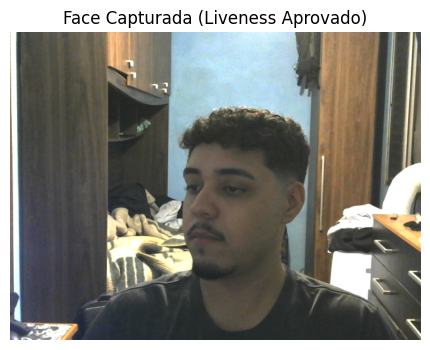

Buscando identidade no banco de dados local...

=== ACESSO NEGADO: Rosto não identificado no banco de dados ===
[EVIDENCIA] Imagem da tentativa salva em: falha_reconhecimento_20260609_200933.jpg
[EVIDENCIA] Log registrado no CSV com sucesso.


False

In [13]:
# 2. Para executar o fluxo de autenticação:
autenticar()

In [9]:
# Listar usuários cadastrados atualmente no banco de dados
usuarios_cadastrados = [f.stem for f in DATABASE_DIR.glob("*.jpg")]
print("Usuários cadastrados no banco de dados local:")
if usuarios_cadastrados:
    for u in usuarios_cadastrados:
        print(f" - {u}")
else:
    print(" (Nenhum usuário cadastrado)")


Usuários cadastrados no banco de dados local:
 (Nenhum usuário cadastrado)


## Nota de Privacidade (LGPD) 🔒

Conforme as disposições da **Lei Geral de Proteção de Dados (LGPD - Lei nº 13.709/2018)**, dados biométricos são classificados como **dados pessoais sensíveis**. 

Para implementações desse sistema em escala comercial ou corporativa:
- **Finalidade e Consentimento**: O usuário deve expressar consentimento explícito e destacado para o tratamento de sua biometria facial, ciente das finalidades de autenticação e prevenção a fraudes.
- **Segurança da Informação**: As fotos originais e/ou os vetores de características gerados devem ser criptografados na origem e no destino.
- **Auditoria de Falhas**: As imagens armazenadas em `failed_attempts` devem ter acesso extremamente restrito e tempo de retenção limitado (ex.: descartadas após 30 dias se nenhuma investigação for aberta).
- **Direito do Titular**: O titular possui direito de solicitar a exclusão de seus dados biométricos a qualquer momento, o que deve invalidar seu cadastro.
